In [39]:
import pandas as pd
import numpy as np
from tabulate import tabulate
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler 
from sklearn.feature_selection import SelectKBest, f_classif

Carga de datos

In [40]:
df_info_equipos = pd.read_csv('../output/equipos_info2.csv')

In [41]:
df_info_equipos.head()

,ID_Equipo,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision,Frecuencia_Mto,Vida_Util,ID_Registro,Fecha_x,...,ID_Orden,Fecha_y,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion,Fallo,Numero_Fallos,Total_Registros,Probabilidad_Fallo
0,1,Compresor,Siemens,Z300,3429.0,7725,22,870072.0,28,2020-01-02 03:00:00,...,799,2020-02-03 06:00:00,Preventivo,404.72,37,Planta Oeste,0,120,330,0.363636
1,1,Compresor,Siemens,Z300,3429.0,7725,22,870072.0,28,2020-01-02 03:00:00,...,837,2020-02-04 20:00:00,Correctivo,7465.08,39,Planta Este,1,120,330,0.363636
2,1,Compresor,Siemens,Z300,3429.0,7725,22,870072.0,28,2020-01-02 03:00:00,...,1344,2020-02-25 23:00:00,Correctivo,7577.35,40,Planta Norte,1,120,330,0.363636
3,1,Compresor,Siemens,Z300,3429.0,7725,22,870072.0,28,2020-01-02 03:00:00,...,1836,2020-03-17 11:00:00,Correctivo,5227.75,17,Planta Oeste,1,120,330,0.363636
4,1,Compresor,Siemens,Z300,3429.0,7725,22,870072.0,28,2020-01-02 03:00:00,...,2103,2020-03-28 14:00:00,Preventivo,6879.63,16,Planta Oeste,0,120,330,0.363636


Hacemos copia para trabajar sobre ella

In [42]:
df_info_equipos_copia= df_info_equipos.copy()

In [43]:
df_info_equipos_copia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178007 entries, 0 to 178006
Data columns (total 23 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   ID_Equipo                    178007 non-null  int64  
 1   Tipo_Equipo                  178007 non-null  object 
 2   Fabricante                   178007 non-null  object 
 3   Modelo                       178007 non-null  object 
 4   Potencia_kW                  178007 non-null  float64
 5   Horas_Recomendadas_Revision  178007 non-null  int64  
 6   Frecuencia_Mto               178007 non-null  int64  
 7   Vida_Util                    178007 non-null  float64
 8   ID_Registro                  178007 non-null  int64  
 9   Fecha_x                      178007 non-null  object 
 10  Temperatura_C                178007 non-null  float64
 11  Vibracion_mm_s               178007 non-null  float64
 12  Horas_Operativas             178007 non-null  float64
 13 

In [44]:
df_info_equipos_copia.head()

,ID_Equipo,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision,Frecuencia_Mto,Vida_Util,ID_Registro,Fecha_x,...,ID_Orden,Fecha_y,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion,Fallo,Numero_Fallos,Total_Registros,Probabilidad_Fallo
0,1,Compresor,Siemens,Z300,3429.0,7725,22,870072.0,28,2020-01-02 03:00:00,...,799,2020-02-03 06:00:00,Preventivo,404.72,37,Planta Oeste,0,120,330,0.363636
1,1,Compresor,Siemens,Z300,3429.0,7725,22,870072.0,28,2020-01-02 03:00:00,...,837,2020-02-04 20:00:00,Correctivo,7465.08,39,Planta Este,1,120,330,0.363636
2,1,Compresor,Siemens,Z300,3429.0,7725,22,870072.0,28,2020-01-02 03:00:00,...,1344,2020-02-25 23:00:00,Correctivo,7577.35,40,Planta Norte,1,120,330,0.363636
3,1,Compresor,Siemens,Z300,3429.0,7725,22,870072.0,28,2020-01-02 03:00:00,...,1836,2020-03-17 11:00:00,Correctivo,5227.75,17,Planta Oeste,1,120,330,0.363636
4,1,Compresor,Siemens,Z300,3429.0,7725,22,870072.0,28,2020-01-02 03:00:00,...,2103,2020-03-28 14:00:00,Preventivo,6879.63,16,Planta Oeste,0,120,330,0.363636


#### *Crear columnas de tiempo día, mes y año*

In [45]:
# Convertir la columna 'fecha' a formato datetime 

df_info_equipos_copia['Fecha_y'] = pd.to_datetime(df_info_equipos_copia['Fecha_y'], format='%Y-%m-%d %H:%M:%S')

# Separar la fecha en día, mes y año 

df_info_equipos_copia['dia'] = df_info_equipos_copia['Fecha_y'].dt.day
df_info_equipos_copia['mes'] = df_info_equipos_copia['Fecha_y'].dt.month
df_info_equipos_copia['año'] = df_info_equipos_copia['Fecha_y'].dt.year

print(df_info_equipos_copia)

        ID_Equipo Tipo_Equipo Fabricante Modelo  Potencia_kW  \
0               1   Compresor    Siemens   Z300       3429.0   
1               1   Compresor    Siemens   Z300       3429.0   
2               1   Compresor    Siemens   Z300       3429.0   
3               1   Compresor    Siemens   Z300       3429.0   
4               1   Compresor    Siemens   Z300       3429.0   
...           ...         ...        ...    ...          ...   
178002        499       Motor    Siemens   Y200       3155.0   
178003        499       Motor    Siemens   Y200       3155.0   
178004        499       Motor    Siemens   Y200       3155.0   
178005        499       Motor    Siemens   Y200       3155.0   
178006        499       Motor    Siemens   Y200       3155.0   

        Horas_Recomendadas_Revision  Frecuencia_Mto  Vida_Util  ID_Registro  \
0                              7725              22   870072.0           28   
1                              7725              22   870072.0           

#### *Determinar las columnas tienen nulos*

In [46]:
df_info_equipos_copia.isnull().sum()


ID_Equipo                      0
Tipo_Equipo                    0
Fabricante                     0
Modelo                         0
Potencia_kW                    0
Horas_Recomendadas_Revision    0
Frecuencia_Mto                 0
Vida_Util                      0
ID_Registro                    0
Fecha_x                        0
Temperatura_C                  0
Vibracion_mm_s                 0
Horas_Operativas               0
ID_Orden                       0
Fecha_y                        0
Tipo_Mantenimiento             0
Costo_Mantenimiento            0
Duracion_Horas                 0
Ubicacion                      0
Fallo                          0
Numero_Fallos                  0
Total_Registros                0
Probabilidad_Fallo             0
dia                            0
mes                            0
año                            0
dtype: int64

#### *Crear columna tiempo de fallo entre mantenimientos (Tpo_Fallo)*

In [47]:

# 2. Ordenar los datos por ID_Equipo y Fecha del mantenimiento
df_info_equipos_copia.sort_values(by=['ID_Equipo', 'Fecha_y'], inplace=True)

# 3. Calcular la diferencia de tiempo entre mantenimientos (en días u horas, según formato de Fecha_y)
df_info_equipos_copia['Tpo_Fallo'] = df_info_equipos_copia.groupby('ID_Equipo')['Fecha_y'].diff()

df_info_equipos_copia.head()
df_info_equipos_copia.shape


(178007, 27)

In [48]:
df_info_equipos_copia.info()


<class 'pandas.core.frame.DataFrame'>
Index: 178007 entries, 0 to 178006
Data columns (total 27 columns):
 #   Column                       Non-Null Count   Dtype          
---  ------                       --------------   -----          
 0   ID_Equipo                    178007 non-null  int64          
 1   Tipo_Equipo                  178007 non-null  object         
 2   Fabricante                   178007 non-null  object         
 3   Modelo                       178007 non-null  object         
 4   Potencia_kW                  178007 non-null  float64        
 5   Horas_Recomendadas_Revision  178007 non-null  int64          
 6   Frecuencia_Mto               178007 non-null  int64          
 7   Vida_Util                    178007 non-null  float64        
 8   ID_Registro                  178007 non-null  int64          
 9   Fecha_x                      178007 non-null  object         
 10  Temperatura_C                178007 non-null  float64        
 11  Vibracion_mm_s    

In [49]:
df_info_equipos_copia['Tpo_Fallo'] = df_info_equipos_copia['Tpo_Fallo'].dt.total_seconds() / (24 * 3600)
df_info_equipos_copia.info()

<class 'pandas.core.frame.DataFrame'>
Index: 178007 entries, 0 to 178006
Data columns (total 27 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   ID_Equipo                    178007 non-null  int64         
 1   Tipo_Equipo                  178007 non-null  object        
 2   Fabricante                   178007 non-null  object        
 3   Modelo                       178007 non-null  object        
 4   Potencia_kW                  178007 non-null  float64       
 5   Horas_Recomendadas_Revision  178007 non-null  int64         
 6   Frecuencia_Mto               178007 non-null  int64         
 7   Vida_Util                    178007 non-null  float64       
 8   ID_Registro                  178007 non-null  int64         
 9   Fecha_x                      178007 non-null  object        
 10  Temperatura_C                178007 non-null  float64       
 11  Vibracion_mm_s               17

### SEPARACIÓN CATEGORICAS Y NUMÉRICAS

In [50]:
# Identificar variables numéricas y categóricas
num_cols = df_info_equipos_copia.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()
cat_cols = df_info_equipos_copia.select_dtypes(include=['object']).columns.tolist()
 
print(f"Variables numéricas: {len(num_cols)}")
print(f"Variables categóricas: {len(cat_cols)}")

Variables numéricas: 20
Variables categóricas: 6


In [51]:
print(num_cols)

['ID_Equipo', 'Potencia_kW', 'Horas_Recomendadas_Revision', 'Frecuencia_Mto', 'Vida_Util', 'ID_Registro', 'Temperatura_C', 'Vibracion_mm_s', 'Horas_Operativas', 'ID_Orden', 'Costo_Mantenimiento', 'Duracion_Horas', 'Fallo', 'Numero_Fallos', 'Total_Registros', 'Probabilidad_Fallo', 'dia', 'mes', 'año', 'Tpo_Fallo']


In [52]:
print(cat_cols)

['Tipo_Equipo', 'Fabricante', 'Modelo', 'Fecha_x', 'Tipo_Mantenimiento', 'Ubicacion']


### ENCODED

Pasamos las columnas categóricas a numéricas para futuro tratamiento a la hora de entrenar modelos

In [53]:
# Paso 2: Aplicar codificación LabelEncoder a las columnas categóricas
label_encoders = {}  # Diccionario para guardar cada encoder si lo necesitas luego
 
for col in cat_cols:
    le = LabelEncoder()
    df_info_equipos_copia[col + '_encoded'] = le.fit_transform(df_info_equipos_copia[col].astype(str))
    label_encoders[col] = le  # Guarda el encoder por si necesitás revertirlo o transformarlo en otro dataset
 
# (Opcional) Ver el nuevo DataFrame
print(df_info_equipos_copia.head())


    ID_Equipo Tipo_Equipo Fabricante Modelo  Potencia_kW  \
0           1   Compresor    Siemens   Z300       3429.0   
22          1   Compresor    Siemens   Z300       3429.0   
44          1   Compresor    Siemens   Z300       3429.0   
66          1   Compresor    Siemens   Z300       3429.0   
88          1   Compresor    Siemens   Z300       3429.0   

    Horas_Recomendadas_Revision  Frecuencia_Mto  Vida_Util  ID_Registro  \
0                          7725              22   870072.0           28   
22                         7725              22   870072.0          482   
44                         7725              22   870072.0         1479   
66                         7725              22   870072.0         1805   
88                         7725              22   870072.0         2591   

                Fecha_x  ...  dia  mes   año  Tpo_Fallo Tipo_Equipo_encoded  \
0   2020-01-02 03:00:00  ...    3    2  2020        NaN                   0   
22  2020-01-21 01:00:00  ...  

Comprobamos que las columnas ahora son numéricas. 

Creamos un dataframe con esas columnas numéricas. 

In [54]:
df_info_equipos_copia_num= df_info_equipos_copia.select_dtypes(include=['int64', 'float64'])
df_info_equipos_copia_num.info()

<class 'pandas.core.frame.DataFrame'>
Index: 178007 entries, 0 to 178006
Data columns (total 23 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   ID_Equipo                    178007 non-null  int64  
 1   Potencia_kW                  178007 non-null  float64
 2   Horas_Recomendadas_Revision  178007 non-null  int64  
 3   Frecuencia_Mto               178007 non-null  int64  
 4   Vida_Util                    178007 non-null  float64
 5   ID_Registro                  178007 non-null  int64  
 6   Temperatura_C                178007 non-null  float64
 7   Vibracion_mm_s               178007 non-null  float64
 8   Horas_Operativas             178007 non-null  float64
 9   ID_Orden                     178007 non-null  int64  
 10  Costo_Mantenimiento          178007 non-null  float64
 11  Duracion_Horas               178007 non-null  int64  
 12  Fallo                        178007 non-null  int64  
 13  Nume

### IDENTIFICAR CONSTANTES

In [55]:
# Identificar las columnas constantes
columnas_constantes = [col 
                       for col in df_info_equipos_copia_num.columns 
                        if df_info_equipos_copia_num[col].nunique() == 1]

print("Columnas constantes:", columnas_constantes)


Columnas constantes: []


Analizamos columnas cuasiconstantes

In [56]:
# Umbral para definir "cuasiconstante" (por ejemplo, 99%)
umbral = 0.98

columnas_cuasiconstantes = [
    col for col in df_info_equipos_copia_num.columns
    if df_info_equipos_copia_num[col].value_counts(normalize=True).max() > umbral
]

print("Columnas cuasiconstantes:", columnas_cuasiconstantes)

Columnas cuasiconstantes: []


Se realiza el escalado de las variables

In [57]:
# Crear un scaler y ajustarlo a los datos
scaler = MinMaxScaler()
df_info_equipos_copia_escalado = pd.DataFrame(scaler.fit_transform(df_info_equipos_copia_num), columns=df_info_equipos_copia_num.columns)

print(df_info_equipos_copia_escalado.head())

   ID_Equipo  Potencia_kW  Horas_Recomendadas_Revision  Frecuencia_Mto  \
0        0.0     0.037456                     0.761262        0.541667   
1        0.0     0.037456                     0.761262        0.541667   
2        0.0     0.037456                     0.761262        0.541667   
3        0.0     0.037456                     0.761262        0.541667   
4        0.0     0.037456                     0.761262        0.541667   

   Vida_Util  ID_Registro  Temperatura_C  Vibracion_mm_s  Horas_Operativas  \
0   0.370028     0.003000       0.437706        0.006303          0.800520   
1   0.370028     0.053450       0.529671        0.023218          0.747921   
2   0.370028     0.164240       0.959772        0.015444          0.952464   
3   0.370028     0.200467       0.971880        0.025109          0.068298   
4   0.370028     0.287810       0.088762        0.036140          0.281555   

   ID_Orden  ...  Numero_Fallos  Total_Registros  Probabilidad_Fallo  \
0  0.079808  .

In [58]:
df_info_equipos_copia_escalado.isnull().sum()

ID_Equipo                        0
Potencia_kW                      0
Horas_Recomendadas_Revision      0
Frecuencia_Mto                   0
Vida_Util                        0
ID_Registro                      0
Temperatura_C                    0
Vibracion_mm_s                   0
Horas_Operativas                 0
ID_Orden                         0
Costo_Mantenimiento              0
Duracion_Horas                   0
Fallo                            0
Numero_Fallos                    0
Total_Registros                  0
Probabilidad_Fallo               0
Tpo_Fallo                      499
Tipo_Equipo_encoded              0
Fabricante_encoded               0
Modelo_encoded                   0
Fecha_x_encoded                  0
Tipo_Mantenimiento_encoded       0
Ubicacion_encoded                0
dtype: int64

In [59]:
df_info_equipos_copia_escalado.fillna(0, inplace=True)

###Estudiar correlaciones 

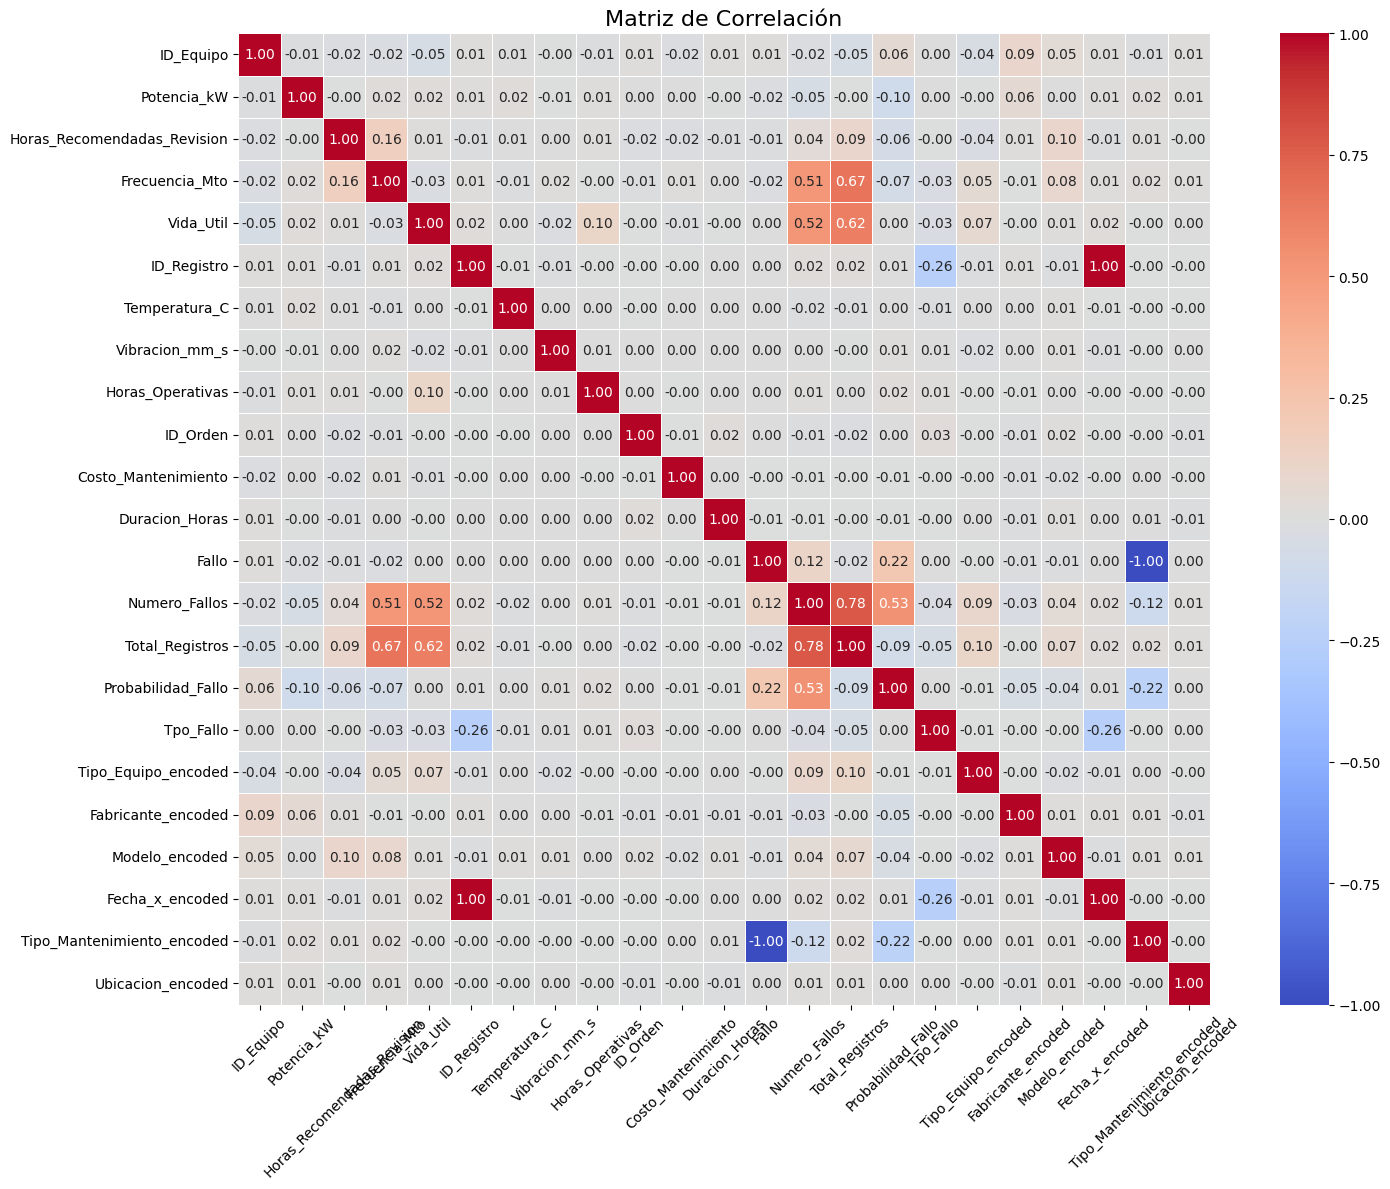

In [60]:
 
# Calcular la matriz de correlación
correlation_matrix = df_info_equipos_copia_escalado.corr()
 
# Configurar tamaño del gráfico
plt.figure(figsize=(16, 12))
 
# Crear el heatmap
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
 
# Título del gráfico
plt.title("Matriz de Correlación", fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
 
# Mostrar el gráfico
plt.show()

Ahora analizaremos las mejores variables a travñes de un SelectKBest

In [61]:
from sklearn.feature_selection import SelectKBest, f_classif

# Verificar las columnas del DataFrame
print("Columnas del DataFrame:", df_info_equipos_copia_escalado.columns)

# Asegurarse de que la columna objetivo esté correctamente especificada
target_column = 'Fallo' 

# Verificar si la columna objetivo existe en el DataFrame
if target_column not in df_info_equipos_copia_escalado.columns:
    raise ValueError(f"La columna objetivo '{target_column}' no se encuentra en el DataFrame.")

# Separar las características (X) y la columna objetivo (y)
X = df_info_equipos_copia_escalado.drop(columns=[target_column])
y = df_info_equipos_copia_escalado[target_column]

# Aplicar SelectKBest para seleccionar las 2 mejores características
selector = SelectKBest(score_func=f_classif, k=2)
X_new = selector.fit_transform(X, y)

# Mostrar las características seleccionadas
selected_features = X.columns[selector.get_support()]
print("Características seleccionadas:", selected_features)


Columnas del DataFrame: Index(['ID_Equipo', 'Potencia_kW', 'Horas_Recomendadas_Revision',
       'Frecuencia_Mto', 'Vida_Util', 'ID_Registro', 'Temperatura_C',
       'Vibracion_mm_s', 'Horas_Operativas', 'ID_Orden', 'Costo_Mantenimiento',
       'Duracion_Horas', 'Fallo', 'Numero_Fallos', 'Total_Registros',
       'Probabilidad_Fallo', 'Tpo_Fallo', 'Tipo_Equipo_encoded',
       'Fabricante_encoded', 'Modelo_encoded', 'Fecha_x_encoded',
       'Tipo_Mantenimiento_encoded', 'Ubicacion_encoded'],
      dtype='object')
Características seleccionadas: Index(['Probabilidad_Fallo', 'Tipo_Mantenimiento_encoded'], dtype='object')


/anaconda/envs/azureml_py38/lib/python3.10/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


In [62]:
# Seleccionar las columnas
columnas_a_eliminar = [
     'ID_Equipo', 'Potencia_kW','Horas_Recomendadas_Revision',
       'Frecuencia_Mto', 'Vida_Util', 'ID_Registro', 'Temperatura_C',
       'Vibracion_mm_s', 'Horas_Operativas', 'ID_Orden', 'Costo_Mantenimiento',
       'Duracion_Horas','Numero_Fallos', 'Total_Registros', 'Tpo_Fallo', 'Tipo_Equipo_encoded',
       'Fabricante_encoded', 'Modelo_encoded', 'Fecha_x_encoded',
       'Ubicacion_encoded'
]
 
# Crear una copia del DataFrame original
df_equipos_best_info = df_info_equipos_copia_escalado.copy()
 
# Eliminar columnas no útiles para el modelo
df_equipos_best_info.drop(columns=columnas_a_eliminar, inplace=True)
 
# Verificar el resultado
print("Columnas restantes:", df_equipos_best_info.columns.tolist())
print(df_equipos_best_info.head())
df_equipos_best_info.shape

Columnas restantes: ['Fallo', 'Probabilidad_Fallo', 'Tipo_Mantenimiento_encoded']
   Fallo  Probabilidad_Fallo  Tipo_Mantenimiento_encoded
0    0.0            0.237537                         1.0
1    0.0            0.237537                         1.0
2    0.0            0.237537                         1.0
3    0.0            0.237537                         1.0
4    0.0            0.237537                         1.0


(178007, 3)

SEPARACIÓN EN TRAIN Y TEST

In [63]:
X_train, X_test, y_train, y_test = train_test_split(df_equipos_best_info, df_equipos_best_info.Fallo, test_size=0.3,
                                                    random_state=0)
X_train.shape, X_test.shape

((124604, 3), (53403, 3))

Una vez separado los datasets para entrenamiento y test, lanzamos a entrenar un modelo Random Forest, teniendo en cuenta que nuestro probelma es de Clasificación

In [64]:
from sklearn.ensemble import RandomForestClassifier

# Entrenar el modelo
modelo_base = RandomForestClassifier(random_state=42)
modelo_base.fit(X_train, y_train)

# Evaluar el modelo
accuracy = modelo_base.score(X_test, y_test)
print(f"Exactitud del modelo base: {accuracy:.2f}")

Exactitud del modelo base: 1.00


Viendo que el accuracy del modelo es 1, deducimos un sobreajuste del mismo. Los datos no reales, pueden generar este overfitting 
Continuamos probando con otros modelos.

Tras probar nuevos modelos y regularizaciones, con el mismo resultado, intentamos optimizar este random forest con otros parametros usando GridSearch. Sigue sobre ajustando y me planteo repasar el df de nuevo

In [67]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, accuracy_score, f1_score

# Definir el modelo
rf = RandomForestClassifier(random_state=42)

# Definir los hiperparámetros a buscar
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
   }

# Definir los scorers
scorers = {
    'accuracy_score': make_scorer(accuracy_score),
    'f1_score': make_scorer(f1_score)
}

# Definir la búsqueda de hiperparámetros
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, scoring=scorers, refit='f1_score', cv=5, verbose=2, n_jobs=-1)

# Ajustar el modelo
grid_search.fit(X_train, y_train)

# Obtener los mejores parámetros
best_params = grid_search.best_params_
print(f"Mejores parámetros: {best_params}")

# Evaluar el modelo con los mejores parámetros
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

# Calcular las métricas
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"F1 Score: {f1}")


Fitting 5 folds for each of 16 candidates, totalling 80 fits


[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.7s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.7s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.7s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.7s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.8s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   3.4s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   3.4s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   3.3s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   3.4s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estim

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Lista de modelos a probar
models = {
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier()
}

# Evaluar cada modelo
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"Resultados para {name}:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(f"F1-Score: {f1_score(y_test, y_pred):.2f}")
    print(f"Precision: {precision_score(y_test, y_pred):.2f}")
    print(f"Recall: {recall_score(y_test, y_pred):.2f}")
    print(f"Matriz de Confusión:\n{confusion_matrix(y_test, y_pred)}\n")


Resultados para Logistic Regression:
Accuracy: 1.00
F1-Score: 1.00
Precision: 1.00
Recall: 1.00
Matriz de Confusión:
[[18005     0]
 [    0 17597]]

Resultados para SVM:
Accuracy: 1.00
F1-Score: 1.00
Precision: 1.00
Recall: 1.00
Matriz de Confusión:
[[18005     0]
 [    0 17597]]

Resultados para Gradient Boosting:
Accuracy: 1.00
F1-Score: 1.00
Precision: 1.00
Recall: 1.00
Matriz de Confusión:
[[18005     0]
 [    0 17597]]

Resultados para KNN:
Accuracy: 1.00
F1-Score: 1.00
Precision: 1.00
Recall: 1.00
Matriz de Confusión:
[[18005     0]
 [    0 17597]]



Probamos con regularizaciones

Pruebo un tes_size de 0,2 y sobre ajusta; luego probamos con 0,3 y pasa lo mismo; añadimos el modelo XGBClassifier
Cambio n_estimator, max_depth... y sigue siento 1. 

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

# Suponiendo que ya tienes tu dataset separado en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Lista de modelos a probar
models = {
    "Logistic Regression": LogisticRegression(penalty='l2', C=0.1),
    "SVM": SVC(kernel='rbf', C=1, gamma=0.1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3),
}

# Evaluar cada modelo
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"Resultados para {name}:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(f"F1-Score: {f1_score(y_test, y_pred):.2f}")
    print(f"Precision: {precision_score(y_test, y_pred):.2f}")
    print(f"Recall: {recall_score(y_test, y_pred):.2f}")
    print(f"Matriz de Confusión:\n{confusion_matrix(y_test, y_pred)}\n")


Resultados para Logistic Regression:
Accuracy: 1.00
F1-Score: 1.00
Precision: 1.00
Recall: 1.00
Matriz de Confusión:
[[26951     0]
 [    0 26452]]

Resultados para SVM:
Accuracy: 1.00
F1-Score: 1.00
Precision: 1.00
Recall: 1.00
Matriz de Confusión:
[[26951     0]
 [    0 26452]]

Resultados para Gradient Boosting:
Accuracy: 1.00
F1-Score: 1.00
Precision: 1.00
Recall: 1.00
Matriz de Confusión:
[[26951     0]
 [    0 26452]]

